<a href="https://colab.research.google.com/github/jomanakhatib/Projects-/blob/main/Regression_Mini-Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining — Linear Regression — Mini-Project 1 (Energy Consumption)

**Course:** [CSEN911] Data Mining (Winter 2025)  
**Instructor:** Dr. Ayman Alserafi  
**Due:** 24 October 2025, 11:59 PM

**Dataset:** `energy_data.csv`  


> **Instructions:** For every step, write your own explanations and justifications and visualization in the provided Markdown prompts.




***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name:

ID:

Tutorial:

---

Name:

ID:

Tutorial:

---


The dataset contains building-level energy readings and contextual attributes.

Each row represents a building observation. Columns include:

<div style="font-size:20px;">

| **Column** | **Description** |
|-------------|-----------------|
| **Building_ID** | Unique identifier for each building record. Used to distinguish one building entry from another. |
| **Building_Type** | Category describing the primary use of the building (e.g., Residential, Commercial, Industrial, Educational, etc.). |
| **Governorate** | The administrative region (governorate) where the building is located (e.g., Cairo, Giza, Alexandria). |
| **Neighborhood** | The smaller district or local area within the governorate where the building is located. |
| **Day_of_Week** | The day on which the energy consumption measurement was recorded (e.g., Sunday, Monday, etc.). |
| **Occupancy_Level** | The relative number of occupants or activity level in the building, typically categorized as *Low*, *Medium*, or *High*. |
| **Appliances_Usage_Level** | Indicates how intensively appliances are used in the building *Low*, *Medium*, or *High*. |
| **SquareFootage** | The total floor area of the building (numeric). Serves as a proxy for building size, often influencing energy usage. |
| **Last_Maintenance_Date** | The date of the last maintainance done on the building. |
| **Average_Temperature** | The average ambient temperature (in °C) recorded during the data period. |
| **Energy_Consumption** | The total energy used by the building, typically measured in kilowatt-hours (kWh).|

</div>


## Importing Libraries & Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh


## Data Inspection

Perform data inspection tasks here (recommended for data understanding).

In [25]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')
print("First 5 rows")
display(df.head())
print("Last 5 rows")
display(df.tail())
print("Counts number of rows and columns")
display(df.shape)
print("Summary of column details")
display(df.describe())
print("Gets out the column type and counts non null values per column")
display(df.info())
print("Count missing values per column")
display(df.isnull().sum())






First 5 rows


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh


Last 5 rows


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
1095,BLD-2095-OH,Commercial,Giza,(Dokki50,Saturday,High,Low,1161m2,2022-04-21,27.85,3010.81 kWh
1096,BLD-2096-RH,Residential,NaN,Dokki-71,Sunday,Medium,Medium,37943m2,2024-10-31,36.23,4248.49 kWh
1097,BLD-2097-JZ,Commercial,Giza,_Mohandessin91,SunDay,Low,Medium,1558,2021-04-18,20.00,2843.6 kWh
1098,BLD-2098-ZP,Industrial,Alexandria,*23Smouha,saturday,Medium,Low,2145,2023-09-14,34.43,3348.39 kWh
1099,BLD-2099-GL,Residential,Cairo,-New Cairo52,friDAY,High,Medium,42414,2020-12-09,40.37,4722.59 kWh


Counts number of rows and columns


...

,Average_Temperature
count,990.000000
mean,33.499404
std,10.703806
min,-4.910000
25%,29.422500
50%,35.260000
75%,39.970000
max,50.000000


Gets out the column type and counts non null values per column
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Building_ID             1100 non-null   object 
 1   Building_Type           990 non-null    object 
 2   Governorate             873 non-null    object 
 3   Neighborhood            1100 non-null   object 
 4   Day_of_Week             1100 non-null   object 
 5   Occupancy_Level         1100 non-null   object 
 6   Appliances_Usage_Level  1100 non-null   object 
 7   SquareFootage           1100 non-null   object 
 8   Last_Maintenance_Date   1100 non-null   object 
 9   Average_Temperature     990 non-null    float64
 10  Energy_Consumption      1100 non-null   object 
dtypes: float64(1), object(10)
memory usage: 94.7+ KB


None

Count missing values per column


,0
Building_ID,0
Building_Type,110
Governorate,227
Neighborhood,0
Day_of_Week,0
Occupancy_Level,0
Appliances_Usage_Level,0
SquareFootage,0
Last_Maintenance_Date,0
Average_Temperature,110


## Data Pre-Processing & Cleaning

_Apply any data preprocessing and/or feature engineering below. Show/output the changes to the dataset._

In [48]:

import pandas as pd
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')
print("Dataset loaded successfully. Original shape:", df.shape)

# Remove extra characters & clean whitespace
df = df.replace({r'\u00a0': ' '}, regex=True)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()

#Normalize categorical text
text_cols = ["Building_Type", "Governorate", "Neighborhood",
             "Day_of_Week", "Occupancy_Level", "Appliances_Usage_Level"]

for col in text_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r'[^A-Za-z\s]', '', regex=True)  # remove symbols and numbers
            .str.lower()
            .str.title()                                 # Captilize first letter per word
            .replace('Nan', np.nan)                      # replace 'Nan' to most freq category
        )

# if governante is missing then we chould check the neighborhood and compare with the same neighborhood in other row then infere it and replace it in the missing one
gov_map = (
    df.groupby("Neighborhood")["Governorate"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan).dropna().to_dict()
)
mask = df["Governorate"].isna() & df["Neighborhood"].notna()
df.loc[mask, "Governorate"] = df.loc[mask, "Neighborhood"].map(gov_map)

# Clean numeric columns by removing any text units and special symbols
df['SquareFootage'] = (
    df['SquareFootage']
    .astype(str)
    .str.replace('m2', '', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

df['Energy_Consumption'] = (
    df['Energy_Consumption']
    .astype(str)
    .str.replace('kWh', '', regex=False)
    .str.replace('[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

#Convert date column to datetime in order to be used in Days_since_last_maintenance column
df['Last_Maintenance_Date'] = pd.to_datetime(df['Last_Maintenance_Date'], errors='coerce')

#Handle missing values
# In Numeric columns by replacing with mean
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

#In Categorical columns by replacing with mode
cat_cols = df.select_dtypes(exclude='number').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#Feature Engineering
# a) Days since last maintenance
df['Days_since_last_maintenance'] = (
    pd.to_datetime('2025-10-01') - df['Last_Maintenance_Date']
).dt.days

# b) Day_type (Weekday/Weekend)
df['Day_type'] = df['Day_of_Week'].apply(
    lambda x: 'Weekend' if x in ['Friday', 'Saturday'] else 'Weekday'
)

display(df.head(6))
display(df.tail())

Dataset loaded successfully. Original shape: (1100, 11)


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption,Days_since_last_maintenance,Day_type
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063.0,2020-01-01,28.610000,2713.95,2100,Weekday
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372.0,2022-02-24,33.499404,5744.99,1315,Weekday
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255.0,2021-02-22,37.880000,4101.24,1682,Weekday
3,BLD-1003-HE,Residential,Giza,Dokki,Tuesday,Low,High,13265.0,2023-07-30,35.060000,3009.14,794,Weekday
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.820000,3279.17,1146,Weekday
5,BLD-1005-VX,Commercial,Cairo,New Cairo,Sunday,Low,Medium,37377.0,2022-07-31,37.540000,4687.67,1158,Weekday


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption,Days_since_last_maintenance,Day_type
1095,BLD-2095-OH,Commercial,Giza,Dokki,Saturday,High,Low,1161.0,2022-04-21,27.85,3010.81,1259,Weekend
1096,BLD-2096-RH,Residential,Giza,Dokki,Sunday,Medium,Medium,37943.0,2024-10-31,36.23,4248.49,335,Weekday
1097,BLD-2097-JZ,Commercial,Giza,Mohandessin,Sunday,Low,Medium,1558.0,2021-04-18,20.00,2843.60,1627,Weekday
1098,BLD-2098-ZP,Industrial,Alexandria,Smouha,Saturday,Medium,Low,2145.0,2023-09-14,34.43,3348.39,748,Weekend
1099,BLD-2099-GL,Residential,Cairo,New Cairo,Friday,High,Medium,42414.0,2020-12-09,40.37,4722.59,1757,Weekend


## Exploratory Data Analysis

**Q1:** What are the most popular neighborhoods? plot all and order them on the graph (mention top 3)

**Visualization**

Top 3 most popular neighborhoods:
 Neighborhood
Smouha    199
Dokki     194
Gleem     189
Name: count, dtype: int64


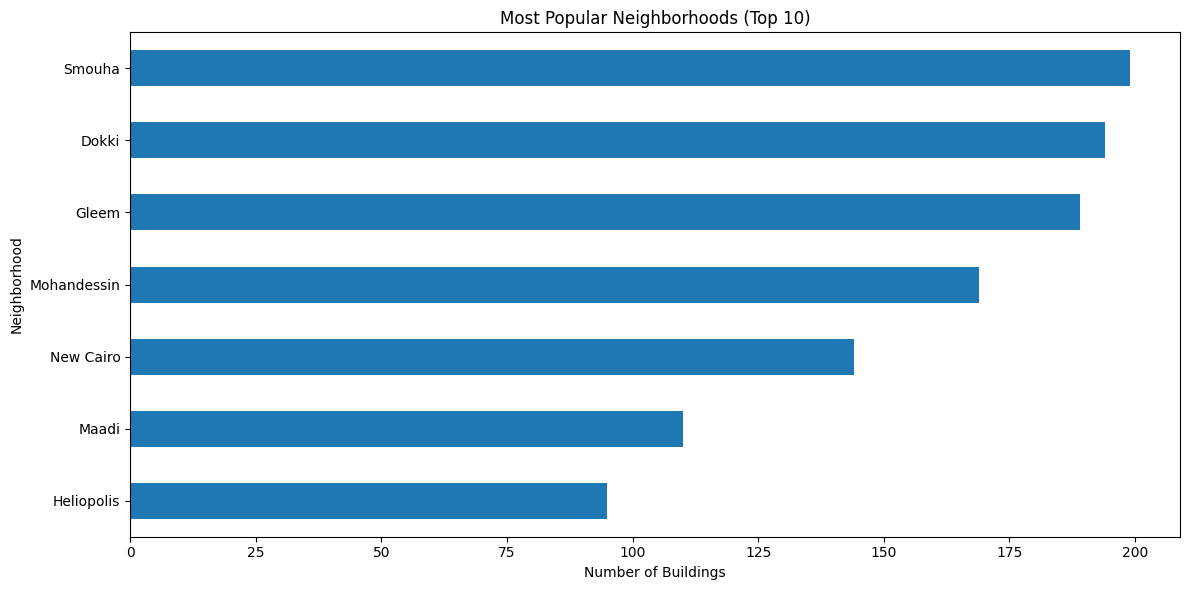

In [50]:
import matplotlib.pyplot as plt #Data visualization library

#Count the total number neighborhood
neighborhood_counts = df['Neighborhood'].value_counts()

#Get the top 3 most frequent neighborhoods
top_3_neighborhoods = neighborhood_counts.head(3)
print("Top 3 most popular neighborhoods:\n", top_3_neighborhoods)

#Create a horizontal bar plot to visualize neighborhood popularity
plt.figure(figsize=(12, 6))
#Sort the top 10 neighbourhoods in ascending order,placing the largest at the top.
neighborhood_counts.head(10).sort_values(ascending=True).plot(kind='barh')
plt.title('Most Popular Neighborhoods (Top 10)')
plt.xlabel('Number of Buildings')
plt.ylabel('Neighborhood')
plt.tight_layout() #In order to prevent overlapping of data adjust the layout
plt.show() #for displaying the plot graph model

**Answer for Q1:** _Your answer here_

In order to visualize the most popular neighborhoods we had analyzed the frequency of buildings located in each neighborhood by getting the top 3 most popular neighborhoods and in order to visualize the results we use bar chart as it's perfectly fits out the idea of comparing categorical data  



**Q2:** Show the distribution of the energy consumption of each Building type.

Which type have the widest distribution of energy consumption?

Which (on average) has the highest consumption?.

**Visualization**

**Answer for Q2:** _Your answer here_

**Q3:** How does the building size affect energy consumption?

**Visualization**

In [ ]:
#chose barplot to make it easier to the eye to detcet the diffrences and detect the trends
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Size_Category',
    y='Energy_Consumption',
    hue='Size_Category', #categories
    palette='magma',#color schema
    legend=False #hide redundant colors
)
#plot the axis
plt.title('Average Energy Consumption by Building Size', fontsize=14)
plt.xlabel('Building Size Category')
plt.ylabel('Average Energy Consumption (kWh)')
plt.tight_layout()
plt.show()

**Answer for Q3:According to what we intreferd from the barplot that the builidng size is positevly correalted to the average energy consumtion, as the building size go bigger the energy consumptions increases;it'll need more equipments and facilities

**Q4:** Do buildings consume more energy if not maintained frequently?

**Visualization**

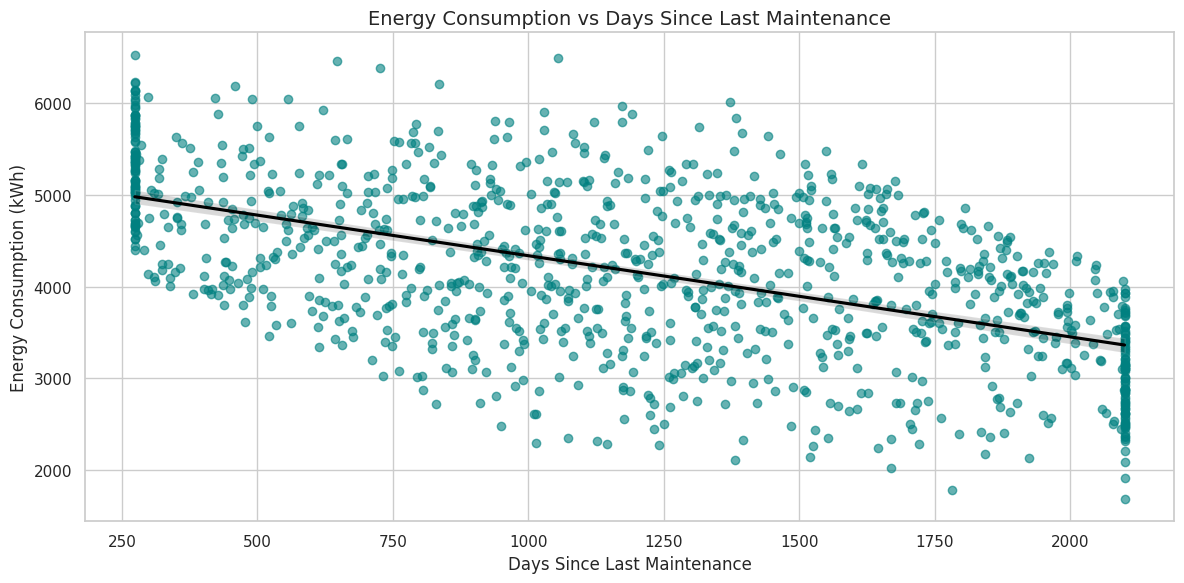

In [51]:
#chose scatter plot in order to show the varity of the numbers and to achieve the best fitting line
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

# Scatter plot with best fitting line
sns.regplot(
    data=df,
    x='Days_since_last_maintenance',
    y='Energy_Consumption',
    scatter_kws={'alpha':0.6, 'color':'teal'},   # scatter dots
    line_kws={'color':'black'}                   # the best line fitting
)
#x axis and y axis
plt.title('Energy Consumption vs Days Since Last Maintenance', fontsize=14)
plt.xlabel('Days Since Last Maintenance')
plt.ylabel('Energy Consumption (kWh)')
plt.tight_layout()
plt.show()

**Answer for Q4:** According to the scatter plot there's a positive relationship between number of days since last maintenance and the building’s energy consumption.
This means that ; when the number of days since last maintenance increase this will increase the energy consumption

**Q5:** Are all the numerical variables normally distributed, or is there any skewness?

**Visualization**

**Answer for Q5:** _Your answer here_

**Q6:** What is multicollinearity? And why is it a problem for linear regression? Does this problem exist in this
dataset?

**Visualization**

**Answer for Q6:** _Your answer here_

## Data Preparation for Modelling

_Apply any additional data preparation steps needed before modelling below. Show/output the changes to the dataset._

## Modelling

_Apply the linear regression model below._

## Model Evaluation

Evaluate the model you applied.

## Conclusion and Recommendations

Comment on the model performance and your findings from model evaluation. State the problems (if any) and suggest possible solutions. Would you recommend this model for an electrcity company aiming to estimate the energy levels of each building?

**Answer**: your answer here.